# Model training

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense

from sentiment_analysis.utils import PATH_CLEANED_TRAINING_DATASET

In [3]:
movie_reviews = pd.read_csv(PATH_CLEANED_TRAINING_DATASET)

In [ ]:
# split into training set (80%), dev set (10%) and test set (10%)
train_df, rem_df = train_test_split(movie_reviews, train_size=0.8, random_state=42)
dev_df, test_df = train_test_split(rem_df, test_size=0.5, random_state=42)

# delete temporary dataframe
del rem_df

print(f"Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}")

Train: 39587 | Dev: 4948 | Test: 4949


In [7]:
# separate features and targets
X_train = train_df["review"].values
y_train = train_df["sentiment"].values
X_dev = dev_df["review"].values
y_dev = dev_df["sentiment"].values
X_test = test_df["review"].values
y_test = test_df["sentiment"].values

## Tokenize

In [8]:
word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(X_train)

In [11]:
# Adding 1 to store dimensions for words for which no pretrained word embeddings exist
vocab_length = len(word_tokenizer.word_index) + 1

In [9]:
X_train = word_tokenizer.texts_to_sequences(X_train)
X_dev = word_tokenizer.texts_to_sequences(X_dev)
X_test = word_tokenizer.texts_to_sequences(X_test)

In [ ]:
# Padding all reviews to fixed length 250
maxlen = 250
padding_type = 'post'

X_train = pad_sequences(X_train, padding=padding_type, maxlen=maxlen)
X_dev = pad_sequences(X_dev, padding=padding_type, maxlen=maxlen)
X_test = pad_sequences(X_test, padding=padding_type, maxlen=maxlen)

In [13]:
print("Sample Padded Sequence (First 10 tokens):")
print(X_train[0][:10])

Sample Padded Sequence (First 10 tokens):
[ 174 2185  204 4838 3754  633 1017   37  447  655]


In [20]:
# Load GloVe word embeddings and create an Embeddings Dictionary

from numpy import asarray
from numpy import zeros

embeddings_dictionary = dict()
glove_file = open('../data/raw/glove.6B.100d.txt', encoding="utf8")

for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary [word] = vector_dimensions
glove_file.close()

In [21]:
# Create Embedding Matrix having 100 columns 
# Containing 100-dimensional GloVe word embeddings for all words in our corpus.

embedding_matrix = zeros((vocab_length, 100))
for word, index in word_tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

In [22]:
embedding_matrix.shape

(90592, 100)

In [24]:
model = Sequential([
    Embedding(vocab_length, 100, weights=[embedding_matrix], trainable=False),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

In [25]:
# Compiling the model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     9,059,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,059,200 (34.56 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,059,200 (34.56 MB)

In [31]:
# Model Training
batch_size=128
epochs=6
lstm_model_history = model.fit(
    X_train, y_train, 
    batch_size=batch_size, 
    epochs=epochs, 
    verbose=1, 
    validation_data=(X_dev, y_dev),
)

Epoch 1/6
310/310 ━━━━━━━━━━━━━━━━━━━━ 81s 260ms/step - accuracy: 0.5052 - loss: 0.6928 - val_accuracy: 0.5220 - val_loss: 0.6907
Epoch 2/6
310/310 ━━━━━━━━━━━━━━━━━━━━ 73s 236ms/step - accuracy: 0.5146 - loss: 0.6908 - val_accuracy: 0.5107 - val_loss: 0.7024
Epoch 3/6
310/310 ━━━━━━━━━━━━━━━━━━━━ 76s 244ms/step - accuracy: 0.5147 - loss: 0.6885 - val_accuracy: 0.4970 - val_loss: 0.6972
Epoch 4/6
310/310 ━━━━━━━━━━━━━━━━━━━━ 76s 245ms/step - accuracy: 0.6167 - loss: 0.6272 - val_accuracy: 0.8131 - val_loss: 0.4393
Epoch 5/6
310/310 ━━━━━━━━━━━━━━━━━━━━ 104s 335ms/step - accuracy: 0.8336 - loss: 0.3827 - val_accuracy: 0.8331 - val_loss: 0.3652
Epoch 6/6
310/310 ━━━━━━━━━━━━━━━━━━━━ 96s 310ms/step - accuracy: 0.8532 - loss: 0.3432 - val_accuracy: 0.8508 - val_loss: 0.3411


In [32]:
score = model.evaluate(X_dev, y_dev, verbose=1)

155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8508 - loss: 0.3411


In [44]:
# Model Performance

print("Validation Score:", score[0])
print("Validation Accuracy:", score[1])

Validation Score: 0.34109583497047424
Validation Accuracy: 0.8508488535881042


In [35]:
lstm_model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

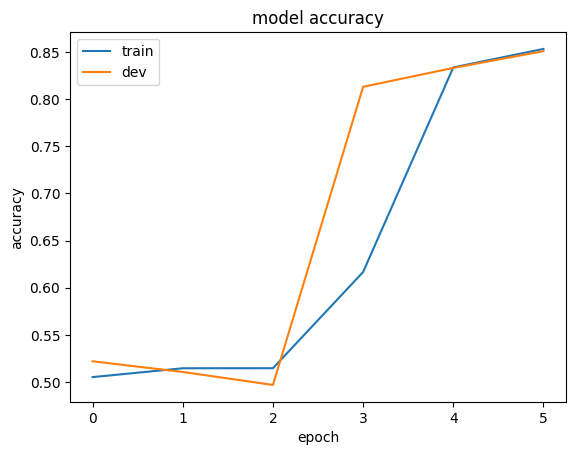

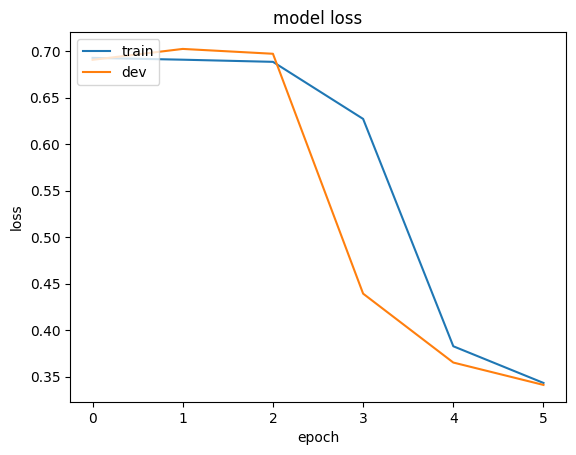

In [36]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(lstm_model_history.history['accuracy'])
plt.plot(lstm_model_history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','dev'], loc='upper left')
plt.show()

plt.plot(lstm_model_history.history['loss'])
plt.plot(lstm_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','dev'], loc='upper left')
plt.show()

In [ ]:
# Saving the model file for use later
from sentiment_analysis.utils import PATH_MODEL

model.save(PATH_MODEL)

# Final evaluation using test datasets

In [45]:
test_score = model.evaluate(X_test, y_test)

155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8513 - loss: 0.3460


In [47]:
# Model Performance

print("Validation Score:", score[0])
print("Validation Accuracy:", score[1])

print("Test Score:", test_score[0])
print("Test Accuracy:", test_score[1])

Validation Score: 0.34109583497047424
Validation Accuracy: 0.8508488535881042
Test Score: 0.3459761142730713
Test Accuracy: 0.851283073425293
